# Task 2: Predict Future Stock Prices (Short-Term)

## Import Libraries

In [1]:
import yfinance as yf
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

## Load Dataset

### Apple Stocks 2020-2025

In [2]:
ticker = 'AAPL'
apple = yf.download(ticker, start='2020-01-01', end='2026-06-06')
apple.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200


### Add a new column

In [4]:
apple['Next_Close'] = apple['Close'].shift(-1)
apple.dropna(inplace=True)
apple.tail()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2026-05-29,312.059998,315.000000,309.529999,311.779999,70026800,306.309998
2026-06-01,306.309998,310.940002,305.019989,309.630005,48849900,315.200012
2026-06-02,315.200012,315.450012,306.690002,307.459991,44534700,310.260010
2026-06-03,310.260010,316.940002,308.850006,314.179993,50836700,311.230011
2026-06-04,311.230011,313.540009,309.649994,313.230011,44869100,307.339996


## Train Models

### Set 80% Training and 20% Testing from the Dataset

In [5]:
X = apple[['Open', 'High', 'Low', 'Volume']]
y = apple[['Next_Close']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train and Analyze the Models

### a) Linear Regression

#### Training the Linear Regression Model

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[0.33,0.34,0.33,0. ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.02]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[1.80e+09,2.62e+03,4.42e+01,4.26e+01]"


#### Predicting using the test data

In [7]:
y_pred_lr = lr.predict(X_test)

df = pd.DataFrame({
    'Actual': y_test.values.flatten(),
    'Predicted': y_pred_lr.flatten()
})

df

,Actual,Predicted
0,93.266983,93.835957
1,226.184906,230.651473
2,211.240143,197.002348
3,192.649323,194.390727
4,156.860931,153.601578
...,...,...
318,154.115265,159.385797
319,122.474243,124.652530
320,171.008286,177.859922
321,234.500961,236.580462


#### Calculating error, and R2 score of Linear Regression Model

In [8]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

df = pd.DataFrame({
    'MAE': [mae_lr],
    'MSE': [mse_lr],
    'R2 Score': [r2_lr]
})

df

,MAE,MSE,R2 Score
0,2.548618,11.665616,0.995988


### b) Random Forest Regressor

#### Training the Random Forest Regressor Model

In [9]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

d:\DevelopersHub Internship Programme\.venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

#### Predicting using the test data

In [10]:
y_pred_rf = rf.predict(X_test)

df = pd.DataFrame({
    'Actual': y_test.values.flatten(),
    'Predicted': y_pred_rf.flatten()
})

df

,Actual,Predicted
0,93.266983,94.133848
1,226.184906,230.927399
2,211.240143,192.167972
3,192.649323,194.384458
4,156.860931,155.828520
...,...,...
318,154.115265,155.750417
319,122.474243,125.817056
320,171.008286,176.379935
321,234.500961,237.469582


#### Calculating error, and R2 score of Random Forest Regressor Model

In [11]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

df = pd.DataFrame({
    'MAE': [mae_rf],
    'MSE': [mse_rf],
    'R2 Score': [r2_rf]
})

df

,MAE,MSE,R2 Score
0,2.58083,13.162339,0.995473


## Plotting the results of Models

### a) Linear Regression

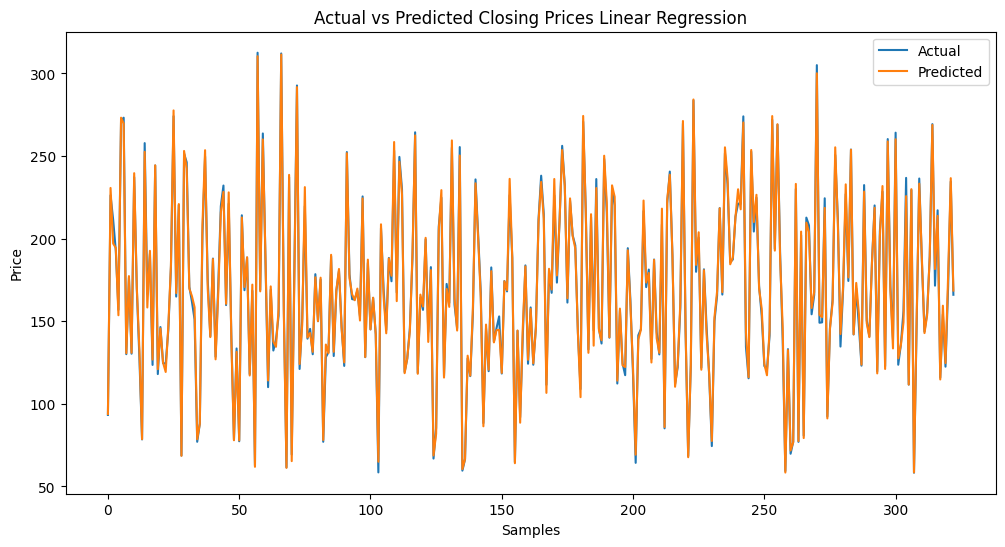

In [12]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    y_pred_lr,
    label='Predicted'
)

plt.title('Actual vs Predicted Closing Prices Linear Regression')

plt.xlabel('Samples')
plt.ylabel('Price')

plt.legend()

plt.show()

### b) Random Forest Regressor

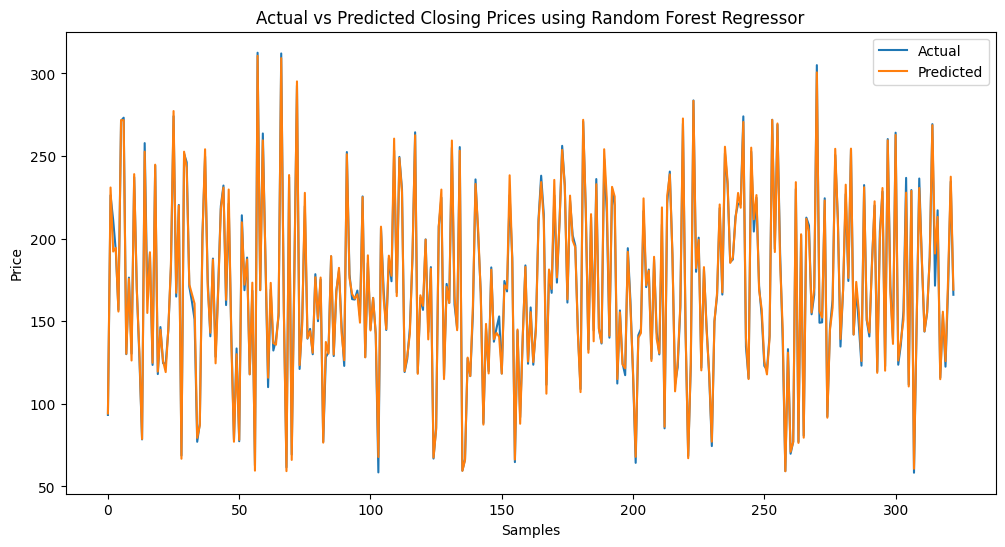

In [13]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    y_pred_rf,
    label='Predicted'
)

plt.title('Actual vs Predicted Closing Prices using Random Forest Regressor')

plt.xlabel('Samples')
plt.ylabel('Price')

plt.legend()

plt.show()

## Comparing MAE, MSE, and R2 Score of both models

In [14]:
df = pd.DataFrame({
    'metrics': ['MAE', 'MSE', 'R2 Score'],
    'Linear Regression': [mae_lr, mse_lr, r2_lr],
    'Random Forest': [mae_rf, mse_rf, r2_rf]
})

df

,metrics,Linear Regression,Random Forest
0,MAE,2.548618,2.580830
1,MSE,11.665616,13.162339
2,R2 Score,0.995988,0.995473
